# Модель експоненційного зростання населення

**Формула:** $y_t = (1 + a)y_{t-1}$, де:
*   $y_t$ — населення в момент часу $t$;
*   $a$ — коефіцієнт приросту.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def simulate_exponential_growth(n0, a, years):
    
    population = [n0]
    
    for t in range(years):
        current_pop = population[-1]
        
        next_pop = (1 + a) * current_pop
        
        population.append(next_pop)
        
    return population

In [ ]:
# --- ЕТАП МОДЕЛЮВАННЯ ДЛЯ РІЗНИХ НАБОРІВ ДАНИХ ---

# Загальні налаштування часу
years = 20

# Початково: 100 осіб, приріст 5% (0.05)
data1 = simulate_exponential_growth(n0=100, a=0.05, years=years)

# Початково: 50 осіб, але високий приріст 15% (0.15)
data2 = simulate_exponential_growth(n0=50, a=0.15, years=years)

# Початково: 500 осіб, від'ємний приріст -5% (-0.05)
data3 = simulate_exponential_growth(n0=500, a=-0.05, years=years)

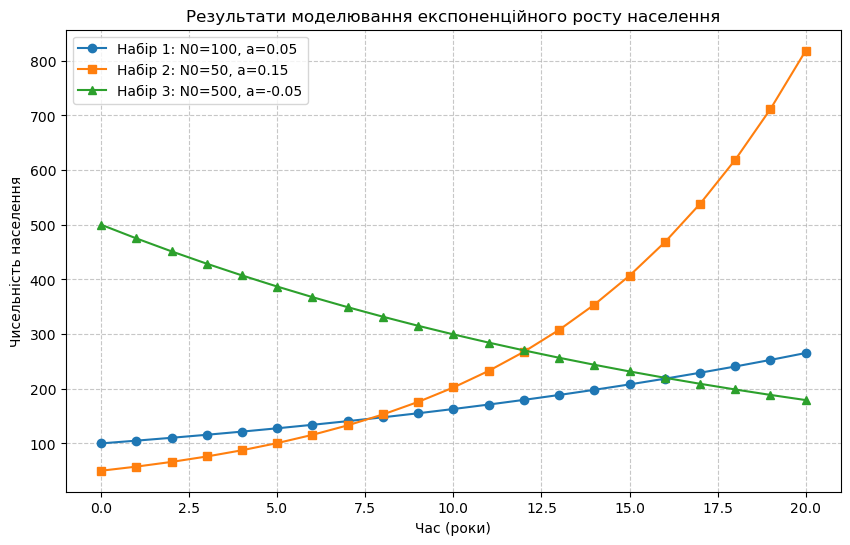

Результат Набір 1 (20 років): 265.33
Результат Набір 2 (20 років): 818.33
Результат Набір 3 (20 років): 179.24


In [ ]:
# --- ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ ---

plt.figure(figsize=(10, 6))

time_axis = range(years + 1)

plt.plot(time_axis, data1, marker='o', label="Набір 1: N0=100, a=0.05")
plt.plot(time_axis, data2, marker='s', label="Набір 2: N0=50, a=0.15")
plt.plot(time_axis, data3, marker='^', label="Набір 3: N0=500, a=-0.05")

plt.title("Результати моделювання експоненційного росту населення")
plt.xlabel("Час (роки)")
plt.ylabel("Чисельність населення")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Модель гонки озброєнь Річардсона

Модель описується системою диференційних рівнянь:

$$
\begin{cases}
\frac{dx}{dt} = ay - mx + r \\
\frac{dy}{dt} = bx - ny + s
\end{cases}
$$

Де:
*   $x, y$ — витрати на озброєння країн X та Y.
*   $a, b$ — коефіцієнти "страху/оборони" (реакція на озброєння сусіда).
*   $m, n$ — коефіцієнти "втоми/економіки" (гальмування через витрати).
*   $r, s$ — коефіцієнти "претензій/образ" (постійні причини конфлікту).

**Умова стійкості:**
*   Якщо $mn - ab > 0$ — система **стійка**.
*   Якщо $mn - ab < 0$ — система **нестійка** (нескінченна гонка озброєнь).

In [ ]:
def richardson_model(params, x0, y0, years, dt=0.1):
    """
    Чисельне моделювання гонки озброєнь методом Ейлера.
    params: словник з коефіцієнтами {a, b, m, n, g, h}
    x0, y0: початкові витрати
    years: час моделювання
    dt: крок часу (менше - точніше)
    """
    steps = int(years / dt)
    t_values = np.linspace(0, years, steps)
    
    x = np.zeros(steps)
    y = np.zeros(steps)
    
    x[0] = x0
    y[0] = y0
    
    a, b = params['a'], params['b']
    m, n = params['m'], params['n']
    g, h = params['g'], params['h']
    
    for i in range(1, steps):
        # Попередні значення
        prev_x = x[i-1]
        prev_y = y[i-1]
        
        # Обчислення похідних (швидкості зміни)
        dxdt = a * prev_y - m * prev_x + g
        dydt = b * prev_x - n * prev_y + h
        
        # Оновлення значень (Метод Ейлера)
        x[i] = prev_x + dxdt * dt
        y[i] = prev_y + dydt * dt
        
    return t_values, x, y

def check_stability(params):
    """Перевірка умови стійкості: mn - ab > 0"""
    val = params['m'] * params['n'] - params['a'] * params['b']
    status = "СТІЙКА (Рівновага)" if val > 0 else "НЕСТІЙКА (Ескалація)"
    return val, status

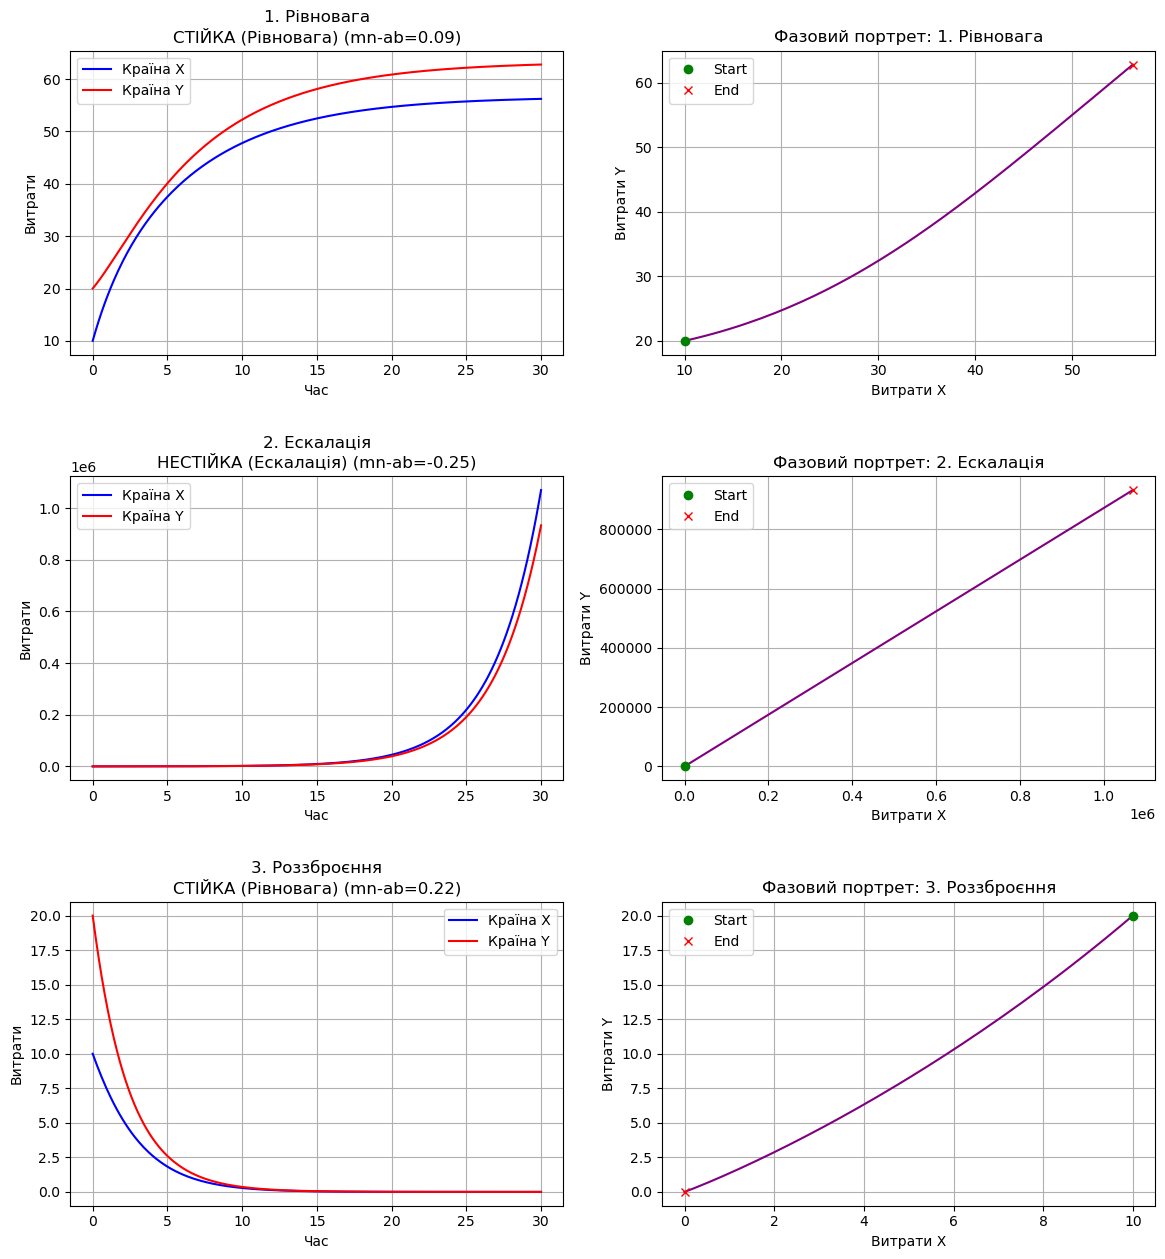

In [ ]:

# --- НАБОРИ ДАНИХ ДЛЯ ЕКСПЕРИМЕНТІВ ---

# Сценарій 1: СТІЙКИЙ МИР (Стримування працює)
# Втома економіки (m, n) вища за страх (a, b)
params_1 = {'a': 0.2, 'm': 0.4, 'g': 10,
            'b': 0.25,'n': 0.35,'h': 8}

# Сценарій 2: НЕСТІЙКА ГОНКА (Ескалація конфлікту)
# Страх (a, b) переважає економіку (m, n)
params_2 = {'a': 0.6, 'm': 0.2, 'g': 20,
            'b': 0.5, 'n': 0.25,'h': 18}

# Сценарій 3: ВЗАЄМНЕ РОЗЗБРОЄННЯ (Дружні стосунки)
# Негативні g та h (співпраця), сильна економія
params_3 = {'a': 0.1, 'm': 0.5, 'g': 0,
            'b': 0.08,'n': 0.45,'h': 0}

scenarios = [
    ("1. Рівновага", params_1),
    ("2. Ескалація", params_2),
    ("3. Роззброєння", params_3)
]

# --- ВІЗУАЛІЗАЦІЯ ---
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plt.subplots_adjust(hspace=0.4)

for i, (name, p) in enumerate(scenarios):
    # Запуск моделі
    t, x, y = richardson_model(p, x0=10, y0=20, years=30)
    
    # Аналіз стійкості
    stab_val, stab_str = check_stability(p)
    title_text = f"{name}\n{stab_str} (mn-ab={stab_val:.2f})"
    
    # Графік 1: Часовий ряд (X(t), Y(t))
    ax_time = axes[i, 0]
    ax_time.plot(t, x, label='Країна X', color='blue')
    ax_time.plot(t, y, label='Країна Y', color='red')
    ax_time.set_title(title_text)
    ax_time.set_xlabel('Час')
    ax_time.set_ylabel('Витрати')
    ax_time.legend()
    ax_time.grid(True)
    
    # Графік 2: Фазовий портрет (Y від X)
    ax_phase = axes[i, 1]
    ax_phase.plot(x, y, color='purple')
    ax_phase.set_title(f"Фазовий портрет: {name}")
    ax_phase.set_xlabel('Витрати X')
    ax_phase.set_ylabel('Витрати Y')
    ax_phase.grid(True)
    
    # Позначка початку і кінця на фазовому портреті
    ax_phase.plot(x[0], y[0], 'go', label='Start') # Зелена точка - старт
    ax_phase.plot(x[-1], y[-1], 'rx', label='End') # Червоний хрестик - кінець
    ax_phase.legend()

plt.show()

# Моделі соціальних процесів на основі клітинних автоматів

1.  **Модель виборця (Voter Model):** Агент просто копіює думку випадкового сусіда. Веде до повного консенсусу (однорідності).
2.  **Модель Шнайда (Sznajd Model):** "Разом ми сила". Якщо двоє сусідів згодні між собою, вони нав'язують свою думку всім своїм сусідам.
3.  **Модель взаємодії (Relative Agreement):** Агенти мають думку від 0 до 1. Впливають одне на одного, тільки якщо їхні думки вже трохи схожі (різниця менша за поріг $\epsilon$).

--- Модель Виборця (30x30, p(+1)=0.6) ---
Консенсус досягнуто за 367029 кроків.
Кінцевий стан: 1 (ЗА).


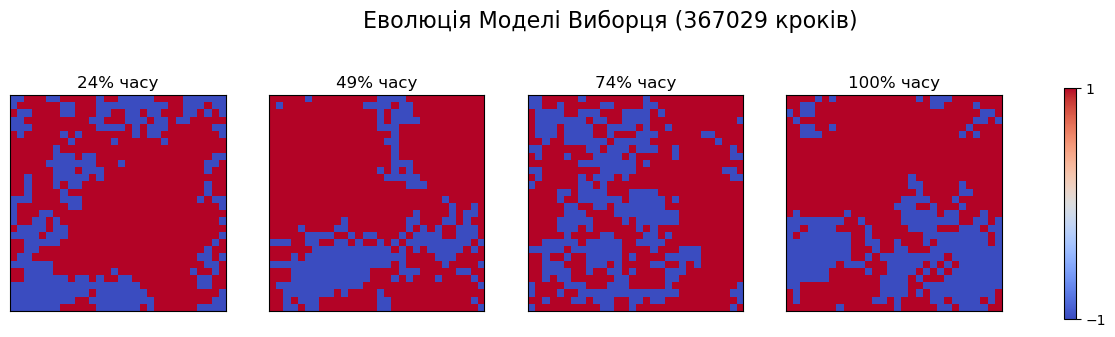

In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy

def visualize_grid_states(grid_states, N, title):
    """
    Візуалізує 4 стани сітки (на 4 квартилях)
    grid_states: список з 4-х кортежів (steps_ratio, grid)
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(title, fontsize=16)

    for i, (steps_ratio, grid) in enumerate(grid_states):
        ax = axes[i]
        
        # Для дискретних моделей (Voter, Sznajd: +1, -1) використовуємо coolwarm
        cmap = plt.cm.coolwarm
        min_val, max_val = -1, 1
        
        # Відображення сітки. Червоний/Синій для +1/-1
        im = ax.imshow(grid, cmap=cmap, vmin=min_val, vmax=max_val)
        
        ax.set_title(f'{int(steps_ratio * 100)}% часу')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Додамо кольорову смугу
    fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.75, ticks=[-1, 1])
    
    plt.show()

# --- ВАШІ ФУНКЦІЇ ---

def initialize_voter_model(N, p_plus):
    """Ініціалізує сітку N x N з початковою густиною p_plus станів +1."""
    # Заповнює сітку значеннями +1 з імовірністю p_plus, і -1 з імовірністю 1 - p_plus
    grid = np.random.choice([1, -1], size=(N, N), p=[p_plus, 1 - p_plus])
    return grid

def is_consensus(grid):
    """Перевіряє, чи досягнуто повного консенсусу (всі +1 або всі -1)."""
    return np.all(grid == grid[0, 0])

def voter_model_step(grid):
    N = grid.shape[0]
    # 1. Випадково обираємо клітину (виборця), що змінює думку
    i, j = random.randint(0, N - 1), random.randint(0, N - 1)
    
    # 2. Випадково обираємо напрямок (сусіда): 8 напрямків (Околиця Мура)
    neighbors = [(-1, -1), (-1, 0), (-1, 1), 
                 (0, -1),         (0, 1), 
                 (1, -1), (1, 0), (1, 1)]
    di, dj = random.choice(neighbors)
    
    # Визначаємо координати сусіда з періодичними граничними умовами
    ni, nj = (i + di) % N, (j + dj) % N
    
    # 3. Виборець копіює думку сусіда
    grid[i, j] = grid[ni, nj]
    
    return grid

def simulate_voter_model(N, p_plus, max_steps):
    grid = initialize_voter_model(N, p_plus)
    steps = 0
    grid_states = []
    
    # Визначаємо цільові кроки для збереження станів
    # Спочатку припускаємо, що консенсус буде досягнутий на max_steps
    target_steps = [int(max_steps * 0.25), int(max_steps * 0.50), int(max_steps * 0.75), max_steps]

    while steps < max_steps:
        # 1. Виконання кроку моделі
        grid = voter_model_step(grid)
        steps += 1
        
        # 2. Збереження стану на квартилях
        if steps in target_steps:
            steps_ratio = steps / max_steps
            # Копіюємо стан сітки, щоб уникнути посилання на об'єкт
            grid_states.append((steps_ratio, copy.deepcopy(grid)))
        
        # 3. Перевірка консенсусу
        if is_consensus(grid):
            break
    
    # Якщо консенсус досягнуто раніше, ніж max_steps, коригуємо кроки
    if steps < max_steps:
        # Очищуємо стани, зібрані за попередніми (неправильними) кроками
        grid_states = []
        
        # Коригуємо цільові кроки відповідно до фактичного часу досягнення консенсусу
        target_steps_actual = [int(steps * 0.25), int(steps * 0.50), int(steps * 0.75)]
        
        # Повертаємося до початкового стану і повторюємо симуляцію, щоб коректно зібрати квартилі
        grid = initialize_voter_model(N, p_plus) # Скидаємо до початкового стану для коректного збору
        current_steps = 0
        
        while current_steps < steps:
            grid = voter_model_step(grid)
            current_steps += 1
            
            if current_steps in target_steps_actual:
                steps_ratio = current_steps / steps
                grid_states.append((steps_ratio, copy.deepcopy(grid)))
        
        # Додаємо фінальний стан (100%)
        grid_states.append((1.0, copy.deepcopy(grid)))
    
    # Якщо консенсус не досягнуто, додаємо фінальний стан, якщо він не був доданий
    if steps == max_steps and len(grid_states) < 4:
         grid_states.append((1.0, copy.deepcopy(grid)))


    final_state = 1 if np.mean(grid) > 0 else -1
    return steps, final_state, grid_states

# --- Обчислювальний експеримент ---
N = 30 # Збільшено розмір сітки до 30x30 для кращої візуалізації
p_plus_initial = 0.60 # Початкова густина +1 (60:40)
max_steps = 1000000

print(f"--- Модель Виборця ({N}x{N}, p(+1)={p_plus_initial}) ---")
steps, result, states = simulate_voter_model(N, p_plus_initial, max_steps)

if steps < max_steps:
    print(f"Консенсус досягнуто за {steps} кроків.")
    print(f"Кінцевий стан: {result} ({'ЗА' if result == 1 else 'ПРОТИ'}).")
    
    # Візуалізація
    visualize_grid_states(states, N, f"Еволюція Моделі Виборця ({steps} кроків)")
    
else:
    print(f"Консенсус не досягнуто за {max_steps} кроків (продовжується).")
    
    # Візуалізація
    visualize_grid_states(states, N, f"Еволюція Моделі Виборця (Прогрес)")


--- Модель Шнайда (50x50, p(+1)=0.525) ---
Консенсус досягнуто за 32023 кроків.
Перемогла думка: ЗА (+1).


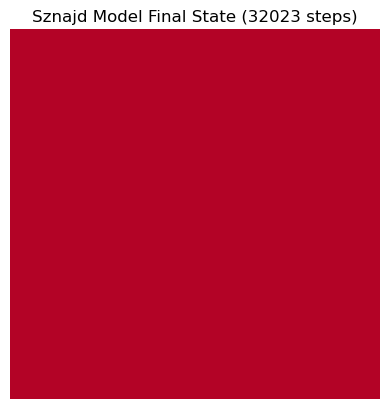

In [77]:
import numpy as np
import random
import matplotlib.pyplot as plt

def initialize_sznajd(N, p_plus):
    """
    Ініціалізація решітки: 1 (ЗА) або -1 (ПРОТИ).
    p_plus - ймовірність появи 1.
    """
    return np.random.choice([1, -1], size=(N, N), p=[p_plus, 1 - p_plus])

def is_consensus(grid):
    """Перевіряє, чи всі клітинки мають однакове значення."""
    return np.all(grid == 1) or np.all(grid == -1)

def sznajd_model_step_corrected(grid):
    N = grid.shape[0]
    
    # 1. Випадково обираємо клітинку (i, j)
    i = random.randint(0, N - 1)
    j = random.randint(0, N - 1)
    
    # 2. Випадково обираємо одного з 4-х сусідів (фон Неймана) для перевірки пари
    neighbors_shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    di, dj = random.choice(neighbors_shifts)
    
    ni = (i + di) % N
    nj = (j + dj) % N
    
    # 3. Перевірка згоди (United we stand)
    if grid[i, j] == grid[ni, nj]:
        opinion = grid[i, j]
        
        # 4. ВПЛИВ НА СУСІДІВ (Згідно з Лістингом 3.7 - цикл по сусідах)
        # Пара переконує сусідів навколо себе (Окіл Мура для пари)
        
        # Список зсувів для 8 сусідів
        # (В спрощеній моделі Шнайда на 2D часто оновлюють сусідів обох елементів пари)
        for check_i, check_j in [(i, j), (ni, nj)]:
            for shift_i in [-1, 0, 1]:
                for shift_j in [-1, 0, 1]:
                    if shift_i == 0 and shift_j == 0:
                        continue
                        
                    target_i = (check_i + shift_i) % N
                    target_j = (check_j + shift_j) % N
                    
                    grid[target_i, target_j] = opinion

    return grid

def simulate_sznajd_model(N, p_plus, max_steps):
    grid = initialize_sznajd(N, p_plus)
    steps = 0
    
    # Початковий стан для візуалізації
    initial_grid = grid.copy()
    
    while not is_consensus(grid) and steps < max_steps:
        grid = sznajd_model_step_corrected(grid)
        steps += 1
        
        # Вивід прогресу, бо 200к кроків це багато
        if steps % 50000 == 0:
            current_mean = np.mean(grid)
            print(f"Крок {steps}, Середнє значення: {current_mean:.4f}")

    final_state = 1 if np.mean(grid) > 0 else -1
    return steps, final_state, grid

# --- Обчислювальний експеримент ---
N = 50 
p_plus_diff = 0.05 
p_plus_initial = 0.5 + p_plus_diff/2 # 0.525
max_steps = 200000 # Для моделі Шнайда 2D часто потрібно більше кроків, ніж для Voter

print(f"\n--- Модель Шнайда ({N}x{N}, p(+1)={p_plus_initial}) ---")
steps, result, final_grid = simulate_sznajd_model(N, p_plus_initial, max_steps)

if steps < max_steps:
    print(f"Консенсус досягнуто за {steps} кроків.")
    print(f"Перемогла думка: {'ЗА (+1)' if result == 1 else 'ПРОТИ (-1)'}.")
else:
    print(f"Консенсус не досягнуто за {max_steps} кроків.")

# Візуалізація результату
plt.imshow(final_grid, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Sznajd Model Final State ({steps} steps)")
plt.axis('off')
plt.show()


--- Модель Взаємодії (50x50, ε=100, m=0.6) ---
Початковий розкид: 255.74 - 0.02
Крок: 50000, Min: 0.3, Max: 252.3, Розкид: 251.9
Крок: 100000, Min: 0.3, Max: 252.3, Розкид: 251.9
Крок: 150000, Min: 0.3, Max: 252.3, Розкид: 251.9
Крок: 200000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 250000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 300000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 350000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 400000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 450000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 500000, Min: 0.3, Max: 246.6, Розкид: 246.3
Крок: 550000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 600000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 650000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 700000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 750000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 800000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 850000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 900000, Min: 2.4, Max: 246.6, Розкид: 244.2
Крок: 950000, Min: 2

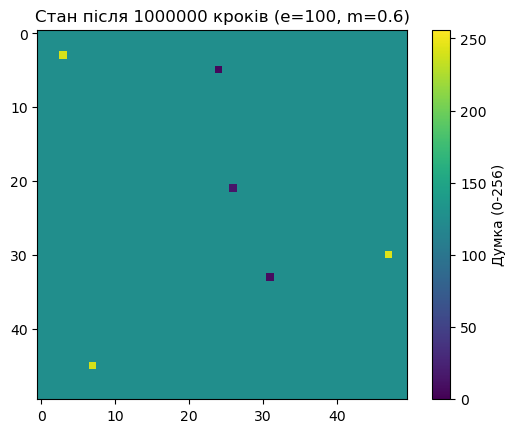

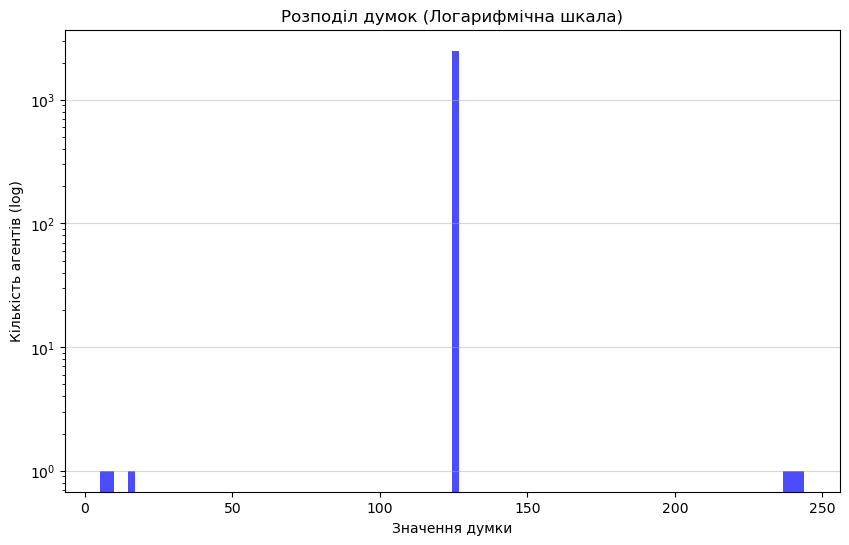

In [74]:
import numpy as np
import random
import matplotlib.pyplot as plt

def initialize_relative_agreement(N):
    # Зміна 1: Використовуємо float для точності обчислень
    return np.random.uniform(0, 256, (N, N))

def relative_agreement_step(grid, epsilon, m):
    N = grid.shape[0]
    
    # Випадковий вибір агентів (як у лістингу 3.4 PDF) [cite: 612]
    ax, ay = random.randint(0, N - 1), random.randint(0, N - 1)
    bx, by = random.randint(0, N - 1), random.randint(0, N - 1)
    
    O_i = grid[ax, ay]
    O_j = grid[bx, by]
    
    diff = O_i - O_j
    
    # Взаємодія відбувається лише якщо погляди "схожі" (< epsilon) [cite: 568]
    if abs(diff) < epsilon:
        change = (m / 2.0) * diff
        
        # Оновлення значень (зближення)
        grid[ax, ay] = O_i - change
        grid[bx, by] = O_j + change
                
    return grid

def simulate_relative_agreement(N, epsilon, m, max_steps):
    grid = initialize_relative_agreement(N)
    
    # Для моніторингу
    check_interval = 5000 
    
    print(f"Початковий розкид: {np.max(grid):.2f} - {np.min(grid):.2f}")
    
    for steps in range(1, max_steps + 1):
        grid = relative_agreement_step(grid, epsilon, m)
        
        if steps % check_interval == 0:
            current_min = np.min(grid)
            current_max = np.max(grid)
            current_spread = current_max - current_min
            
            # Якщо розкид дуже малий (наприклад < 1), вважаємо це консенсусом для float
            if current_spread < 1.0: 
                return steps, current_spread, grid
            
            if steps % 50000 == 0:
                print(f"Крок: {steps}, Min: {current_min:.1f}, Max: {current_max:.1f}, Розкид: {current_spread:.1f}")

    final_spread = np.max(grid) - np.min(grid)
    return max_steps, final_spread, grid

# --- Параметри ---
N = 50 
epsilon = 100    # Спробуйте змінити на 150, щоб гарантувати консенсус
m = 0.6       
max_steps = 1000000 

print(f"\n--- Модель Взаємодії ({N}x{N}, ε={epsilon}, m={m}) ---")
steps, final_spread, final_grid = simulate_relative_agreement(N, epsilon, m, max_steps)

if final_spread < 1.0:
    print(f"Повний консенсус досягнуто за {steps} кроків.")
else:
    print(f"Симуляцію завершено. Консенсусу немає (сформовано кластери або не вистачило часу).")
    print(f"Кінцевий розкид: {final_spread:.2f}")

# Візуалізація
plt.imshow(final_grid, cmap='viridis', vmin=0, vmax=256)
plt.colorbar(label='Думка (0-256)')
plt.title(f"Стан після {steps} кроків (e={epsilon}, m={m})")
plt.show()

# Гістограма думок (щоб побачити кластери/екстремістів)
plt.figure(figsize=(10, 6))
# log=True переводить вісь Y в логарифмічний масштаб
plt.hist(final_grid.flatten(), bins=100, color='blue', alpha=0.7, log=True) 
plt.title("Розподіл думок (Логарифмічна шкала)")
plt.xlabel("Значення думки")
plt.ylabel("Кількість агентів (log)")
plt.grid(axis='y', alpha=0.5)
plt.show()

# Модель сегрегації населення

### Логіка моделі:
1.  **Поле:** Решітка, де живуть агенти двох типів (наприклад, Сині та Червоні) + порожні клітинки.
2.  **Щастя агента:** Агент задоволений, якщо серед його сусідів певний відсоток (поріг `threshold`) є "своїми" (такого ж кольору).
    *   *Наприклад:* Агент хоче, щоб хоча б 30% сусідів були такими ж, як він.
3.  **Переїзд:** Якщо агент нещасливий, він переїжджає на випадкову **порожню** клітинку.

In [ ]:
# Константи станів клітинок
EMPTY = 0
GROUP_A = 1
GROUP_B = 2

In [46]:
def initialize_grid(size, empty_ratio):
    """
    Створює початкову сітку з випадковим розподілом агентів.
    """
    n_cells = size * size
    n_empty = int(n_cells * empty_ratio)
    n_agents = n_cells - n_empty
    n_group_a = n_agents // 2
    n_group_b = n_agents - n_group_a

    population = [EMPTY] * n_empty + [GROUP_A] * n_group_a + [GROUP_B] * n_group_b
    random.shuffle(population)

    return np.array(population).reshape(size, size)

In [47]:
def is_unhappy(grid, x, y, threshold):
    """
    Перевіряє, чи задоволений агент своїм оточенням (окіл Мура).
    """
    agent_type = grid[x, y]
    if agent_type == EMPTY:
        return False

    rows, cols = grid.shape
    same_count = 0
    total_neighbors = 0

    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            if i == 0 and j == 0:
                continue

            nx, ny = x + i, y + j
            if 0 <= nx < rows and 0 <= ny < cols:
                neighbor_type = grid[nx, ny]
                if neighbor_type != EMPTY:
                    total_neighbors += 1
                    if neighbor_type == agent_type:
                        same_count += 1

    if total_neighbors == 0:
        return False

    similarity_ratio = same_count / total_neighbors
    return similarity_ratio < threshold

In [48]:
def run_simulation(grid, threshold, max_iters):
    """
    Запускає процес міграції агентів.
    """
    rows, cols = grid.shape
    history = [grid.copy()]

    for it in range(max_iters):
        unhappy_agents = []
        empty_spots = []

        for r in range(rows):
            for c in range(cols):
                if grid[r, c] == EMPTY:
                    empty_spots.append((r, c))
                elif is_unhappy(grid, r, c, threshold):
                    unhappy_agents.append((r, c))

        if not unhappy_agents:
            print(f"Консенсус досягнуто на ітерації {it}")
            break

        random.shuffle(unhappy_agents)
        random.shuffle(empty_spots)

        while unhappy_agents and empty_spots:
            old_x, old_y = unhappy_agents.pop()
            new_x, new_y = empty_spots.pop()

            grid[new_x, new_y] = grid[old_x, old_y]
            grid[old_x, old_y] = EMPTY

        if it % 10 == 0:
            history.append(grid.copy())

    history.append(grid.copy())
    return history

Консенсус досягнуто на ітерації 12


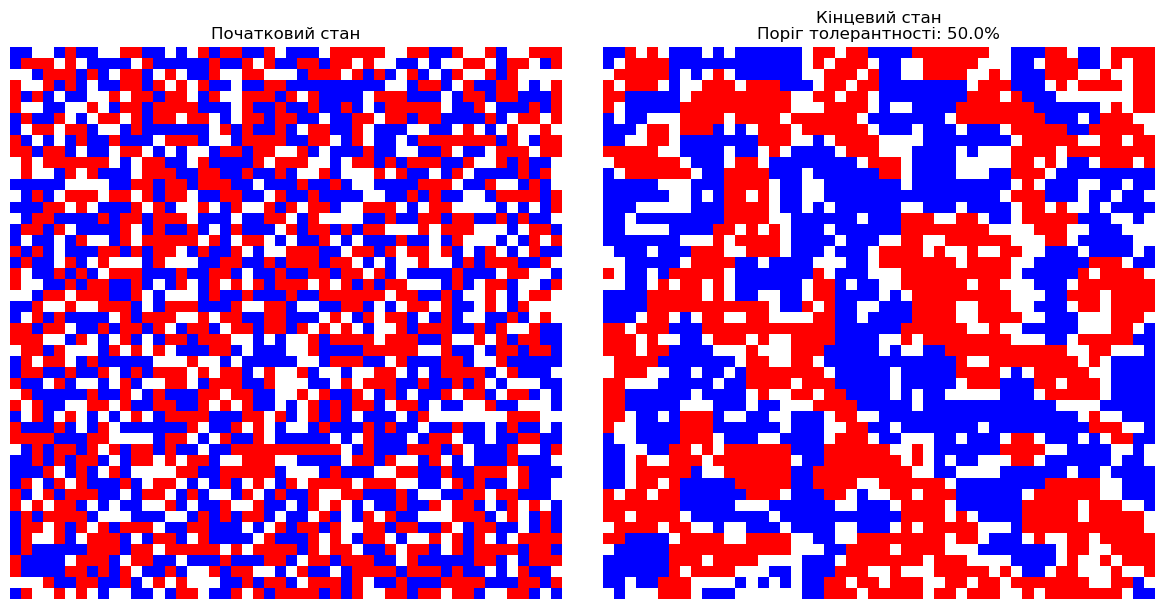

In [57]:
# --- КОНФІГУРАЦІЯ МОДЕЛІ ---
GRID_SIZE = 50                # Розмір сітки (50x50)
EMPTY_RATIO = 0.25            # Відсоток порожніх будинків
SIMILARITY_THRESHOLD = 0.5    # Мінімальна частка "своїх" сусідів
MAX_ITERATIONS = 500          # Максимальна кількість ітерацій
import matplotlib.colors as mcolors

def plot_results(history):
    """
    Малює початковий і фінальний стан моделі.
    """
    cmap = mcolors.ListedColormap(['white', 'blue', 'red'])
    bounds = [0, 0.5, 1.5, 2.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(history[0], cmap=cmap, norm=norm)
    axs[0].set_title("Початковий стан")
    axs[0].axis('off')

    axs[1].imshow(history[-1], cmap=cmap, norm=norm)
    axs[1].set_title(
        f"Кінцевий стан\nПоріг толерантності: {SIMILARITY_THRESHOLD*100}%"
    )
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

grid = initialize_grid(GRID_SIZE, EMPTY_RATIO)
history = run_simulation(grid, SIMILARITY_THRESHOLD, MAX_ITERATIONS)
plot_results(history)